# Transformasi Citra: Translasi, Rotasi, Skala, dan Flip

- Nama  : Muhammad Zaidaan Ardiyansyah
- NIM   : 24060124140200
- Kelas : E  



In [2]:
%pip install numpy matplotlib pillow 

Note: you may need to restart the kernel to use updated packages.


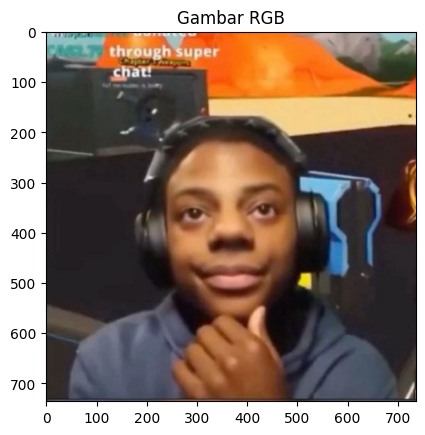

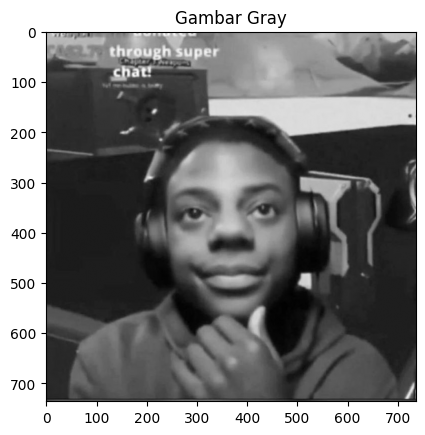

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import math
import typing

imgRGB = Image.open('speed.jpg').convert('RGB')
imgArrayRGB = np.array(imgRGB)

imgGray = Image.open('speed.jpg').convert('L')
imgArrayGray = np.array(imgGray)

plt.imshow(imgArrayRGB)
plt.title('Gambar RGB')
plt.show()

plt.imshow(imgArrayGray, cmap='gray')
plt.title('Gambar Gray')
plt.show()

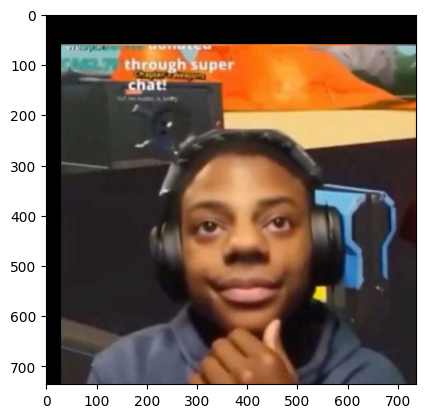

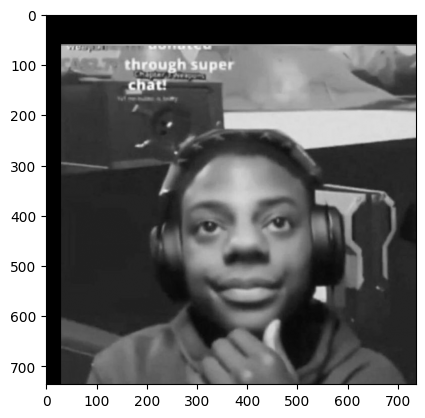

In [4]:
def translate(img: np.ndarray, m, n):
    M, N = img.shape[:2]
    output = np.zeros_like(img)

    for x in range(M):
        for y in range(N):
            newX = x + m
            newY = y + n

            if 0 <= newX < M and 0 <= newY < N:
                output[newX, newY] = img[x, y]
    
    return output

imgTranslatedRGB = translate(imgArrayRGB, 60, 30)
plt.imshow(imgTranslatedRGB)
plt.show()

imgTranslatedGray = translate(imgArrayGray, 60, 30)
plt.imshow(imgTranslatedGray, cmap='gray')
plt.show()

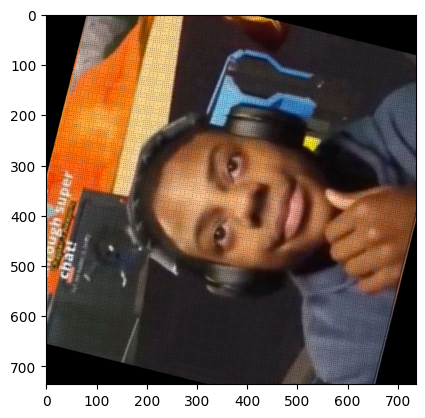

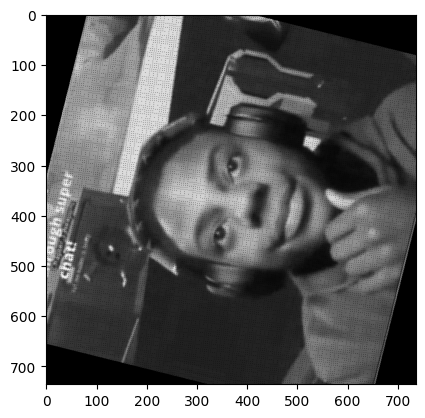

In [5]:
def rotate(img: np.ndarray, angle):
    M, N = img.shape[:2]
    radian = np.radians(angle)
    output = np.zeros_like(img)
    centerX, centerY = M // 2, N // 2

    for x in range(M):
        for y in range(N):
            tempX = x - centerX
            tempY = y - centerY

            newX = int(tempX * math.cos(radian) - tempY * math.sin(radian)) + centerX
            newY = int(tempX * math.sin(radian) + tempY * math.cos(radian)) + centerY

            if 0 <= newX < M and 0 <= newY < N:
                output[newX, newY] = img[x, y]

    return output

imgRotatedRGB = rotate(imgArrayRGB, 76)
plt.imshow(imgRotatedRGB)
plt.show()

imgRotatedGray = rotate(imgArrayGray, 76)
plt.imshow(imgRotatedGray, cmap='gray')
plt.show()

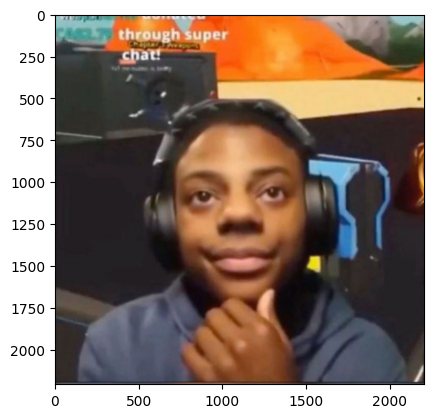

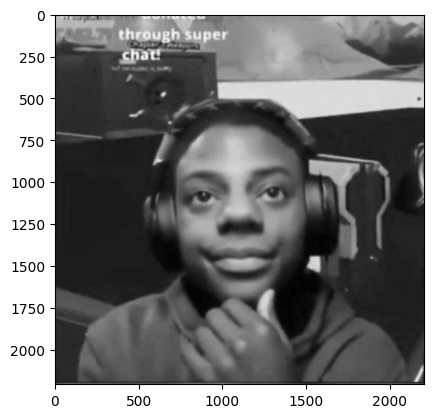

Ukuran original: 736px
Setelah scaling gambar (rgb) 3x: 2208px
Setelah scaling gambar (gray) 3x: 2208px


In [6]:
def scale(img: np.ndarray, factor):
    M, N = img.shape[:2]
    newM = int(M * factor)
    newN = int(N * factor)

    if img.ndim == 3:
        newCanvas = (newM, newN, img.shape[2])
    else:
        newCanvas = (newM, newN)
    output = np.zeros(newCanvas, dtype=np.uint8)

    for x in range(newM):
        for y in range(newN):
            originalX = int(x / factor)
            originalY = int(y / factor)

            if originalX >= M: originalX = M - 1
            if originalY >= N: originalY =  - 1

            output[x, y] = img[originalX, originalY]

    return output


scalingFactor = 3

imgScaledRGB = scale(imgArrayRGB, scalingFactor)
plt.imshow(imgScaledRGB)
plt.show()

imgScaledGray = scale(imgArrayGray, scalingFactor)
plt.imshow(imgScaledGray, cmap='gray')
plt.show()

print(f"Ukuran original: {len(imgArrayGray)}px")
print(f"Setelah scaling gambar (rgb) {scalingFactor}x: {len(imgScaledRGB)}px")
print(f"Setelah scaling gambar (gray) {scalingFactor}x: {len(imgScaledGray)}px")

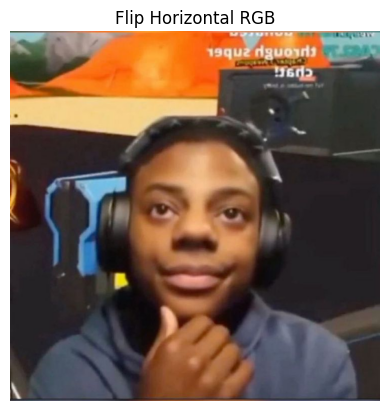

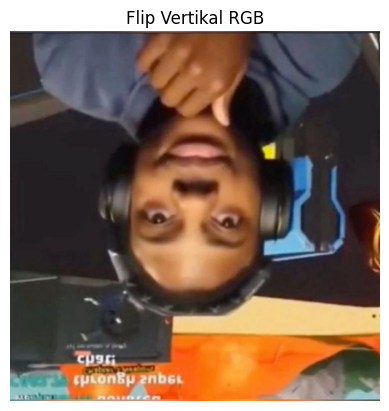

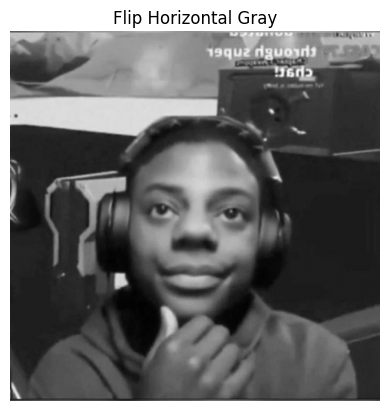

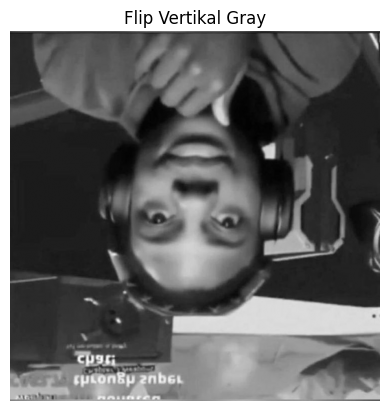

In [8]:
def flip(img: np.ndarray, mode: typing.Literal['horizontal', 'vertical']):
    M, N = img.shape[:2]
    output = np.zeros_like(img)

    for x in range(M):
        for y in range(N):
            if mode == 'horizontal':
                output[x, N - 1 - y] = img[x, y]
            elif mode == 'vertical':
                output[M - 1 - x, y] = img[x, y]

    return output

imgFlippedHorizontalRGB = flip(imgArrayRGB, 'horizontal')
imgFlippedVerticalRGB = flip(imgArrayRGB, 'vertical')

imgFlippedHorizontalGray = flip(imgArrayGray, 'horizontal')
imgFlippedVerticalGray = flip(imgArrayGray, 'vertical')

plt.imshow(imgFlippedHorizontalRGB)
plt.title('Flip Horizontal RGB')
plt.axis('off')
plt.show()

plt.imshow(imgFlippedVerticalRGB)
plt.title('Flip Vertikal RGB')
plt.axis('off')
plt.show()

plt.imshow(imgFlippedHorizontalGray, cmap='gray')
plt.title('Flip Horizontal Gray')
plt.axis('off')
plt.show()

plt.imshow(imgFlippedVerticalGray, cmap='gray')
plt.title('Flip Vertikal Gray')
plt.axis('off')
plt.show()